### KNN Regression



In [11]:
import numpy as np

class KNN:
    def __init__(self):
        '''
        Initializes the KNN regressor.
        '''
        pass # No initialization needed for this simple KNN class

    @staticmethod
    def euclidean_distance(point1: np.ndarray, point2: np.ndarray) -> float:
        '''
        Calculates the Euclidean distance between two NumPy array points.

        Args:
            point1 (np.ndarray): The first point.
            point2 (np.ndarray): The second point.

        Returns:
            float: The Euclidean distance between the two points.
        '''
        return np.sqrt(np.sum((point1 - point2)**2))

    def knn_search(self, X_train: np.ndarray, query_point: np.ndarray, k: int) -> list:
        '''
        Finds the k nearest neighbors to a query_point from the X_train dataset.

        Args:
            X_train (np.ndarray): Training input features.
            query_point (np.ndarray): The point for which to find neighbors.
            k (int): The number of nearest neighbors to find.

        Returns:
            list: A list of indices of the k nearest neighbors in X_train.
        '''
        distances = []
        for i, train_point in enumerate(X_train):
            dist = self.euclidean_distance(train_point, query_point)
            distances.append((dist, i))

        # Sort by distance and get the indices of the k nearest neighbors
        distances.sort(key=lambda x: x[0])
        k_nearest_indices = [idx for dist, idx in distances[:k]]
        return k_nearest_indices

    def predict(self, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, k: int) -> np.ndarray:
        '''
        Predicts target values for new input data X_test using KNN regression.

        Args:
            X_train (np.ndarray): Training input features.
            y_train (np.ndarray): Training target values.
            X_test (np.ndarray): New input features for prediction.
            k (int): The number of nearest neighbors to consider.

        Returns:
            np.ndarray: An array of predicted target values for X_test.
        '''
        predictions = []
        for query_point in X_test:
            # Find k nearest neighbors
            k_nearest_indices = self.knn_search(X_train, query_point, k)

            # Get the y_train values of the k neighbors
            k_nearest_y = y_train[k_nearest_indices]

            # Predict by averaging the y values of the k neighbors
            prediction = np.mean(k_nearest_y)
            predictions.append(prediction)

        print("KNN class and predict method implemented and ready for use.")
        return np.array(predictions)


Load and prepare the Iris dataset.



In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np

iris = load_iris()

# Select features and target
# Features: Petal Length (index 2), Petal Width (index 3)
# Target: Sepal Length (index 0)

X = iris.data[:, [2, 3]]  # Petal Length and Petal Width
y = iris.data[:, 0]   # Sepal Length

# Ensure X is 2D and y is 1D (already handled by slicing)
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Iris dataset loaded, features and target selected, and split into training/testing sets successfully.")

Shape of X: (150, 2)
Shape of y: (150,)
X_train shape: (105, 2)
X_test shape: (45, 2)
y_train shape: (105,)
y_test shape: (45,)
Iris dataset loaded, features and target selected, and split into training/testing sets successfully.


Train and Evaluate KNN Regression



In [13]:
from sklearn.metrics import mean_squared_error

# 1. Instantiate the KNN class
knn_regressor = KNN()

# 2. Set a suitable value for k
k_neighbors = 5

# 3. Use the predict method to make predictions on the X_test data
y_pred = knn_regressor.predict(X_train, y_train, X_test, k=k_neighbors)

# 4. Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 5. Print the calculated MSE
print(f"KNN Regression Mean Squared Error (MSE) with k={k_neighbors}: {mse:.4f}")

KNN class and predict method implemented and ready for use.
KNN Regression Mean Squared Error (MSE) with k=5: 0.1247


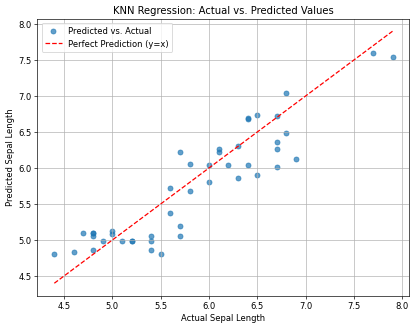

Actual vs. Predicted values plot displayed.


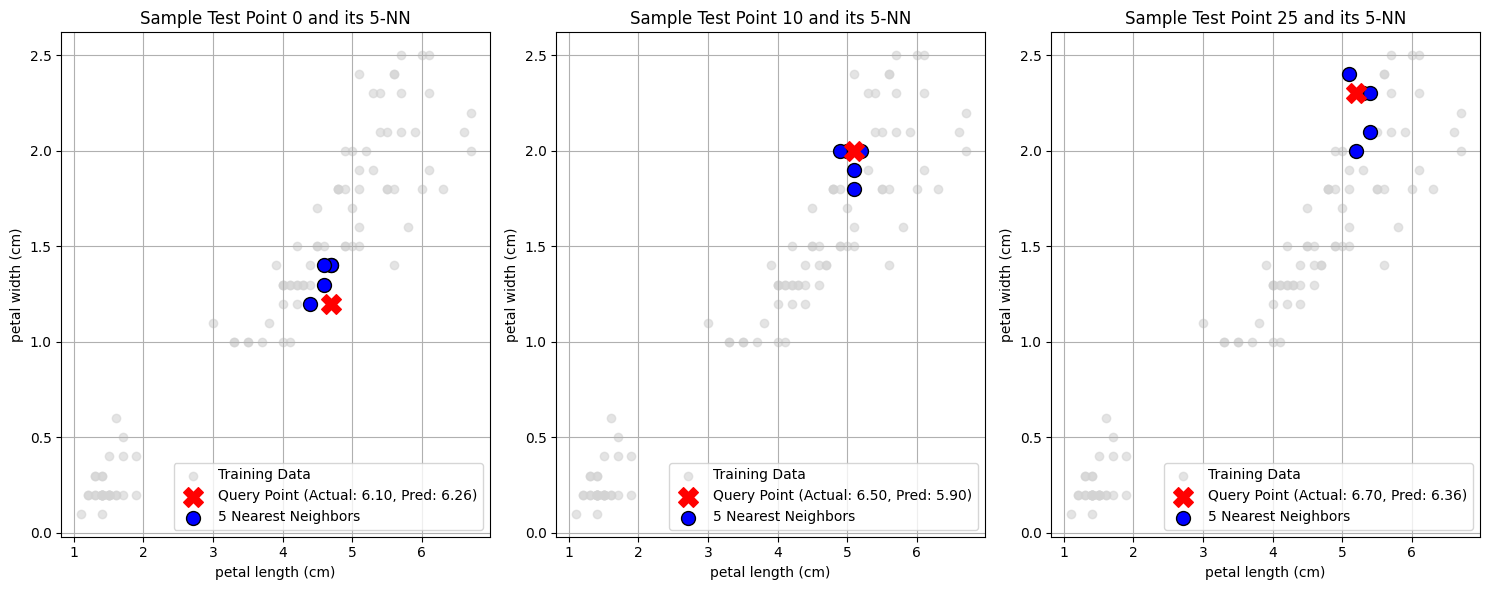

K-Nearest Neighbors visualization for sample test points displayed.


In [14]:
import matplotlib.pyplot as plt

# Plot 1: Actual vs. Predicted Values
plt.figure(figsize=(8, 6), dpi=60)
plt.scatter(y_test, y_pred, alpha=0.7, label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction (y=x)')
plt.xlabel('Actual Sepal Length')
plt.ylabel('Predicted Sepal Length')
plt.title('KNN Regression: Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

print("Actual vs. Predicted values plot displayed.")

# Plot 2: Visualization of k-Nearest Neighbors for Sample Test Points
# Choose a few sample indices from the test set to visualize their neighbors
sample_indices_to_plot = [0, 10, 25] # Arbitrarily selected indices for visualization

plt.figure(figsize=(15, 6)) # Adjust figure size for multiple subplots if needed

for idx, sample_test_idx in enumerate(sample_indices_to_plot):
    query_point = X_test[sample_test_idx]
    actual_value = y_test[sample_test_idx]
    predicted_value = y_pred[sample_test_idx]

    # Find k nearest neighbors
    k_nearest_indices = knn_regressor.knn_search(X_train, query_point, k=k_neighbors)

    # Create a subplot for each sample point
    plt.subplot(1, len(sample_indices_to_plot), idx + 1)

    # Plot all training data points
    plt.scatter(X_train[:, 0], X_train[:, 1], c='lightgray', label='Training Data', alpha=0.6)

    # Highlight the query point (test point)
    plt.scatter(query_point[0], query_point[1], c='red', marker='X', s=200, label=f'Query Point (Actual: {actual_value:.2f}, Pred: {predicted_value:.2f})', zorder=5)

    # Highlight the k nearest neighbors
    knn_points = X_train[k_nearest_indices]
    plt.scatter(knn_points[:, 0], knn_points[:, 1], c='blue', marker='o', s=100, label=f'{k_neighbors} Nearest Neighbors', edgecolors='black', zorder=4)

    plt.xlabel(iris.feature_names[2]) # Petal Length
    plt.ylabel(iris.feature_names[3]) # Petal Width
    plt.title(f'Sample Test Point {sample_test_idx} and its {k_neighbors}-NN')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

print("K-Nearest Neighbors visualization for sample test points displayed.")